<a href="https://colab.research.google.com/github/Artomic2020/Break_the_Universe/blob/main/Assignment2_IDATG2208_26_AdultCensus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Machine Learning — IDATG2208 bold text NTNU Gjøvik

Student: Art Olson
Date: September 2026

Assignment 2
Adult Census Income dataset

Q1.1 Identify and quantify missing values per feature. Determine whether the missing-ness looks random or is concentrated in specific subgroups (e.g., check if missing occupation correlates with workclass). Choose and justify a strategy for handling them (e.g., imputation vs. removal, and which imputation statistic), and explainany risks your chosen strategy introduces.

Imputation vs removal. which?  average, null, most common or random within a range, for example.

In [76]:
import sklearn.datasets

# Load the 'adult' dataset from OpenML.org
adult_data = sklearn.datasets.fetch_openml(name="adult", version=2, as_frame=True)

# The actual DataFrame is in the 'data' key of the returned object
df_adult = adult_data['data']

# Display the first 5 rows of the 'adult' dataset
display(df_adult.head())

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States


In [77]:
# a. Data types and non-null counts
df_adult.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       46043 non-null  category
 2   fnlwgt          48842 non-null  int64   
 3   education       48842 non-null  category
 4   education-num   48842 non-null  int64   
 5   marital-status  48842 non-null  category
 6   occupation      46033 non-null  category
 7   relationship    48842 non-null  category
 8   race            48842 non-null  category
 9   sex             48842 non-null  category
 10  capital-gain    48842 non-null  int64   
 11  capital-loss    48842 non-null  int64   
 12  hours-per-week  48842 non-null  int64   
 13  native-country  47985 non-null  category
dtypes: category(8), int64(6)
memory usage: 2.6 MB


In [78]:
# b. Summary statistics
df_adult.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [79]:
# c. Dataset dimensions

df_adult.shape

(48842, 14)

In [80]:

# d. Column names
df_adult.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country'],
      dtype='object')

In [81]:
# e. Missing values per feature
df_adult.isnull().sum()

,0
age,0
workclass,2799
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,2809
relationship,0
race,0
sex,0


Ok, the method is null() with sum shows that workclass has 2799 null values, occupation has 2809 null values, and native country has 857 null values. It seems that "unspecified' could be a labal especially for native-country, while occupation and work class could be also important..I guess it might be important to see how many have null values in all three and or two categories or one.  Also what might help infer the missing data reliably. Random imputation is probably not a good choice, because it could distort things. Throwing out fields with missing data might also be ok, but it might amount to a large proportion of the data. Loosing 5000 out of 48000 for example, probably wont affect our training unless all of the mislabeled data is from one aspect.


In [82]:
cols = ['workclass', 'occupation', 'native-country']

df_adult[cols].isnull().sum(axis=1).value_counts().sort_index()

,count
0,45222
1,821
2,2753
3,46


In [83]:
missing_both = df_adult[
    df_adult['workclass'].isnull() &
    df_adult['occupation'].isnull()
]

missing_both.shape


(2799, 14)

In [84]:
other_missing = df_adult[
    df_adult['native-country'].isnull() |
    (df_adult['occupation'].isnull() & df_adult['workclass'].notnull())
]
len(other_missing)

867

In [85]:
other_missing.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,867.000000,867.000000,867.000000,867.000000,867.000000,867.000000
mean,38.554787,193838.930796,10.649366,1732.740484,93.785467,40.892734
std,12.695681,96390.304053,3.048380,10919.363376,418.564340,12.471724
min,17.000000,22245.000000,1.000000,0.000000,0.000000,1.000000
25%,29.000000,130620.000000,9.000000,0.000000,0.000000,40.000000
50%,37.000000,180656.000000,10.000000,0.000000,0.000000,40.000000
75%,46.000000,230046.000000,13.000000,0.000000,0.000000,45.000000
max,90.000000,647882.000000,16.000000,99999.000000,3004.000000,99.000000


In [86]:
df_adult.describe().loc[['mean', '50%']]

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
mean,38.643585,189664.134597,10.078089,1079.067626,87.502314,40.422382
50%,37.000000,178144.500000,10.000000,0.000000,0.000000,40.000000


In [87]:
df_adult = df_adult.drop(other_missing.index)

df_adult.shape
df_adult.isnull().sum()

,0
age,0
workclass,2753
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,2753
relationship,0
race,0
sex,0


At this point I think the fields still missing data are missing data in both categories; occupation and workclass.  This could be further investigated as it indicates a discrepancey in data collection in certain industries i.e workclass or occupational sectors. If they are all concentrated in one specified class the omition could skew the data.

After removing approximately 1.47% of rows with individual empty data values.
The remaining missing values (2753) occur almost entirely simultaneously in workclass and occupation, suggesting that the missing-ness may result from a common data-collection or classification issue or some group of workers that are not classifiable. Because these observations represent approximately 5.7% of the dataset, removing them without further investigation could introduce bias if the missing records are concentrated within a particular subgroup, for example among women or of a certain education, age group or regaion.  It could be important to improve data collection or analyse further if we can see trends.

In [88]:
missing_work = df_adult[
    df_adult['workclass'].isnull() &
    df_adult['occupation'].isnull()
]

In [89]:
missing_work.describe(include='all')

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
count,2753.000000,0,2.753000e+03,2753,2753.000000,2753,0,2753,2753,2753,2753.000000,2753.000000,2753.000000,2753
unique,NaN,0,NaN,16,NaN,7,0,6,5,2,NaN,NaN,NaN,38
top,NaN,NaN,NaN,Some-college,NaN,Never-married,NaN,Own-child,White,Male,NaN,NaN,NaN,United-States
freq,NaN,NaN,NaN,822,NaN,1211,NaN,858,2279,1507,NaN,NaN,NaN,2530
mean,40.242644,NaN,1.871897e+05,NaN,9.235016,NaN,NaN,NaN,NaN,NaN,505.867054,67.567744,31.804214,NaN
std,20.293450,NaN,1.077599e+05,NaN,2.540296,NaN,NaN,NaN,NaN,NaN,4656.416383,363.550385,15.107025,NaN
min,17.000000,NaN,1.228500e+04,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN
25%,21.000000,NaN,1.161650e+05,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,20.000000,NaN
50%,34.000000,NaN,1.754310e+05,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,36.000000,NaN
75%,61.000000,NaN,2.331820e+05,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN


In [90]:
for col in missing_work.columns:
    print(f"\n--- {col} ---")
    print(missing_work[col].value_counts(dropna=False))


--- age ---
age
19    183
20    181
18    152
21    145
22    125
     ... 
82      5
84      4
83      2
87      2
89      1
Name: count, Length: 71, dtype: int64

--- workclass ---
workclass
NaN                 2753
Federal-gov            0
Local-gov              0
Private                0
Never-worked           0
Self-emp-inc           0
Self-emp-not-inc       0
State-gov              0
Without-pay            0
Name: count, dtype: int64

--- fnlwgt ---
fnlwgt
41356     4
139391    4
38455     3
191118    3
334593    3
         ..
216639    1
20057     1
239900    1
213366    1
83783     1
Name: count, Length: 2595, dtype: int64

--- education ---
education
Some-college    822
HS-grad         801
Bachelors       245
11th            178
10th            147
7th-8th         107
Assoc-voc        79
Assoc-acdm       72
9th              69
Masters          65
12th             58
5th-6th          41
Prof-school      23
1st-4th          18
Doctorate        18
Preschool        10
Name: count

In [91]:
df_adult['workclass'] = (
    df_adult['workclass']
    .cat.add_categories('Unknown')  # Need to add "unknown" as a categorical value before imputing Null values
    .fillna('Unknown')
)

df_adult['occupation'] = (
    df_adult['occupation']
    .cat.add_categories('Unknown')
    .fillna('Unknown')
)



'Unknown' is introduced as a category label for the 2,753 observations with jointly missing workclass and occupation. This preserves the observations and allows their missing employment information to be treated as an identifiable group in subsequent analysis.  So now the dataset is cleaned and contains o=no null values.

In [92]:
df_adult.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


Q1.2 Detect outliers in the numerical features (e.g., age, hours-per-week, capital-gain, capital-loss) using both the IQR method and z-scores. Report how many points each method flags per feature, and decide, with justification, whether to cap, remove, or keep them, considering how tree-based models and SVMs respond differently to outliers.

In [93]:
df_adult.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,47975.000000,4.797500e+04,47975.000000,47975.000000,47975.000000,47975.000000
mean,38.645190,1.895887e+05,10.067764,1067.254508,87.388765,40.413882
std,13.728277,1.057626e+05,2.560392,7374.008991,402.721453,12.389955
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.173160e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781000e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.377245e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [94]:
# Identify numerical features for outlier detection
numerical_features = ['age', 'capital-gain', 'capital-loss', 'hours-per-week']

print("Outlier Detection using IQR Method")
for col in numerical_features:
    Q1 = df_adult[col].quantile(0.25)
    Q3 = df_adult[col].quantile(0.75)
    IQR = Q3 - Q1  # IQR Method measures the range or distance between first and third quartiles
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR  #(1.5 * IQR is a conventional threshold (Tukey's))

    outliers_iqr = df_adult[(df_adult[col] < lower_bound) | (df_adult[col] > upper_bound)]
    print(f"Feature '{col}': {len(outliers_iqr)} outliers detected by IQR method.")

print("\n Outlier Detection using Z-score Method")
for col in numerical_features:
    # Calculate Z-scores   (z score measures how many standard deviations this value is above or below the mean)
    mean = df_adult[col].mean()
    std = df_adult[col].std()
    df_adult['z_score_' + col] = (df_adult[col] - mean) / std

    # A common threshold for outliers is a Z-score absolute value greater than 3
    outliers_zscore = df_adult[abs(df_adult['z_score_' + col]) > 3]
    print(f"Feature '{col}': {len(outliers_zscore)} outliers detected by Z-score method (threshold: 3).")

    # Drop the temporary z_score column
    df_adult = df_adult.drop(columns=['z_score_' + col])

Outlier Detection using IQR Method
Feature 'age': 211 outliers detected by IQR method.
Feature 'capital-gain': 3961 outliers detected by IQR method.
Feature 'capital-loss': 2239 outliers detected by IQR method.
Feature 'hours-per-week': 13263 outliers detected by IQR method.

 Outlier Detection using Z-score Method
Feature 'age': 181 outliers detected by Z-score method (threshold: 3).
Feature 'capital-gain': 320 outliers detected by Z-score method (threshold: 3).
Feature 'capital-loss': 2173 outliers detected by Z-score method (threshold: 3).
Feature 'hours-per-week': 668 outliers detected by Z-score method (threshold: 3).


Capping or removing age outliers (well under 1%) probably wouldn't have much effect overall and might inadvertently remove other useful information from those rows. There is also little justification for removing them simply because they are statistically unusual. Capital loss is strongly tied to a highly skewed, zero-dominated distribution, so removing its outliers could distort the estimates by removing or obscuring the relatively small but meaningful group of non-zero values. Generally, we want to preserve valid data rather than artificially correcting patterns in the distribution simply because they appear statistically unusual. Therefore, detected outliers should be retained unless there is evidence that they represent erroneous data.

Decision Trees and Random Forests are relatively tolerant of outliers because their splits are based on thresholds and class separation rather than numerical distance.  SVMs maximize the distance between lines of separation, and so outliers can have more effect, especially when when it happens to appear near or disrupt the SVM's decision boundary.

The IQR Method measures the range or distance between first and third quartiles.
IQR ignores much of the fourth quartile, but captures its extreme upper end for the purposr of flagging outliers. With Q1 = Q3 = 0, the IQR method effectively says every person with any capital gain is an outlier, but these values should not be removed.

z score measures how many standard deviations this value is above or below the mean. In z-scores for this example the standard deviation could be misleading; while it is mathematically correct. i.e. A SD of $7374 in capital gains doesnt represent a typical observation for most of the observations, which have a capital gains value of 0.

Q1.3 Several categorical features are high-cardinality (e.g., native-country, occupation). Quantify the cardinality of each categorical feature and propose a strategy for the high-cardinality ones (e.g., grouping rare categories into an ”other” bucket, frequency thresholding). Justify your chosen threshold and show how it changes the category counts.

In [95]:
df_adult.nunique()

,0
age,74
workclass,8
fnlwgt,28215
education,16
education-num,16
marital-status,7
occupation,15
relationship,6
race,5
sex,2


In [96]:
df_adult.select_dtypes(include=['object', 'category']).nunique()  #nunique() returns cardinality

,0
workclass,8
education,16
marital-status,7
occupation,15
relationship,6
race,5
sex,2
native-country,41


In [97]:
df_adult['occupation'].value_counts(normalize=True) * 100

,proportion
occupation,
Craft-repair,12.548202
Prof-specialty,12.523189
Exec-managerial,12.473163
Adm-clerical,11.547681
Sales,11.272538
Other-service,10.021886
Machine-op-inspct,6.190724
Unknown,5.738405
Transport-moving,4.827514


In [98]:
df_adult['workclass'].value_counts(normalize=True) * 100  # value_counts()

,proportion
workclass,
Private,69.425743
Self-emp-not-inc,7.912454
Local-gov,6.461699
Unknown,5.738405
State-gov,4.056279
Self-emp-inc,3.430954
Federal-gov,2.930693
Without-pay,0.043773
Never-worked,0.000000


In [99]:
occupation_counts = df_adult['occupation'].value_counts() # value_counts()

occupation_counts[occupation_counts < 20]

,count
occupation,
Armed-Forces,14


In [100]:


counts = df_adult['native-country'].value_counts()

print("Under 20:",  (counts < 20).sum())
print("Under 50:",  (counts < 50).sum())
print("Under 100:", (counts < 100).sum())
print("Under 200:", (counts < 200).sum())

Under 20: 2
Under 50: 17
Under 100: 26
Under 200: 37


In [101]:
df_adult['native-country'].value_counts().head(5) # shows the top 5

,count
native-country,
United-States,43822
Mexico,951
Philippines,295
Germany,206
Puerto-Rico,184


Most categorical features have sufficient representation, although a few categories have very low frequencies, such as Armed-Forces (14), Hungary (19), and Netherlands (1). These categories could be poorly represented after train/test splitting. Countries could potentially be grouped into larger geographic regions (Asia, Africa, N. America, Europe, etc) to reduce cardinality, although this would require introducing categories not provided by the original dataset.  

Value counts could be scrutinized further. 20 samples is probably not a stable set. After an 80/20 split, this would leave approximately 16 training and 4 test observations, hardly reliable.  value_counts for "native-country" show that for 26 countries, the sample size for individual countries is possibly too few (100 or less).

.head(5) shows that the dataset is overwhelmingly represented by samples from USA (43822), then Mexico (951), etc. and representative sample rates drop off quickly, under 200 collected for most countries. These low-frequency categories could result in less reliable patterns after train/test splitting, but the original categories are retained because reducing or removing them would significantly alter the international scope of the dataset.

In [102]:
df_adult['native-country'].value_counts()

,count
native-country,
United-States,43822
Mexico,951
Philippines,295
Germany,206
Puerto-Rico,184
Canada,182
El-Salvador,155
India,151
Cuba,138


We'll make a region_map as a dictionary with key:value pairs defining region-values that correspond to 'native-country':


In [103]:
# region_map is a dictionary with key:value pairs defining region-values that correspond to 'native-country'

region_map = {
    # North America
    'United-States': 'North America',
    'Canada': 'North America',
    'Mexico': 'North America',

    # Central America & Caribbean
    'Puerto-Rico': 'Central America & Caribbean',
    'El-Salvador': 'Central America & Caribbean',
    'Cuba': 'Central America & Caribbean',
    'Jamaica': 'Central America & Caribbean',
    'Dominican-Republic': 'Central America & Caribbean',
    'Guatemala': 'Central America & Caribbean',
    'Haiti': 'Central America & Caribbean',
    'Nicaragua': 'Central America & Caribbean',
    'Trinadad&Tobago': 'Central America & Caribbean',
    'Honduras': 'Central America & Caribbean',

    # South America
    'Columbia': 'South America',
    'Peru': 'South America',
    'Ecuador': 'South America',

    # Europe
    'Germany': 'Europe',
    'England': 'Europe',
    'Italy': 'Europe',
    'Poland': 'Europe',
    'Portugal': 'Europe',
    'Greece': 'Europe',
    'France': 'Europe',
    'Ireland': 'Europe',
    'Yugoslavia': 'Europe',
    'Scotland': 'Europe',
    'Hungary': 'Europe',
    'Holand-Netherlands': 'Europe',

    # Asia
    'Philippines': 'Asia',
    'India': 'Asia',
    'China': 'Asia',
    'Japan': 'Asia',
    'Vietnam': 'Asia',
    'Taiwan': 'Asia',
    'Iran': 'Asia',
    'Hong': 'Asia',
    'Thailand': 'Asia',
    'Cambodia': 'Asia',
    'Laos': 'Asia',

    # Original categories that don't map cleanly
    'Outlying-US(Guam-USVI-etc)': 'Other/Unclear',
    'South': 'Other/Unclear'
}

In [104]:
df_adult['region'] = df_adult['native-country'].map(region_map)  # .map() creates a new regional category column instead of overwriting 'native-country'

.map() creates a new regional category column based on the region_map indexing instead of overwriting 'native-country'

In [105]:
print(df_adult['region'].value_counts(dropna=False))

region
North America                  44955
Asia                             981
Central America & Caribbean      945
Europe                           780
South America                    176
Other/Unclear                    138
Name: count, dtype: int64


The counts are good.

Encode the categorical features using an appropriate technique (e.g., one-hot en
coding, target encoding, or ordinal encoding where suitable) and justify your choice.Discuss how the encoding affects the dimensionality of the feature space, and how it interacts with your high-cardinality strategy from the previous question.

In [106]:
print(df_adult.shape)
print(df_adult.columns.tolist())

(47975, 15)
['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'region']


Q1.5 Compute a correlation matrix (or association measure suitable for mixed types e.g., Cramer’s V for categorical pairs) among the features. Plot it as a heatmap and identify any pairs with strong multicollinearity. Discuss why multicollinearity is a concern for a linear SVM but less so for a Decision Tree.

Cramer’s V is used to measure the strength of association between two nominal (or categorical) variables. As a measure of association it ranges from 0 through 1, where:

0 indicates that there is no association between the two variables, and
1 indicates that there is a strong association between the two variables.
Cramer’s V uses the chi-square test statistic in its calculation, the sample size, and the crosstab’s dimensions.

Chi-squares test is used to examine whether two categorical variables are independent in influencing the test statistic.

In [114]:
def cramers_v(cross_tab):
    X2 = stats.chi2_contingency(cross_tab, correction=False)[0]
    phi2 = X2 / cross_tab.sum().sum()
    n_rows, n_cols = cross_tab.shape
    return (phi2 / min(n_cols - 1, n_rows - 1)) ** 0.5

In [112]:
# Correlation matrix for numerical features
correlation_matrix = df_adult.select_dtypes(include='number').corr()

correlation_matrix

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
age,1.000000,-0.076806,0.030745,0.076984,0.056561,0.070512
fnlwgt,-0.076806,1.000000,-0.040271,-0.003537,-0.004442,-0.014041
education-num,0.030745,-0.040271,1.000000,0.125602,0.081396,0.144635
capital-gain,0.076984,-0.003537,0.125602,1.000000,-0.031407,0.082887
capital-loss,0.056561,-0.004442,0.081396,-0.031407,1.000000,0.053328
hours-per-week,0.070512,-0.014041,0.144635,0.082887,0.053328,1.000000


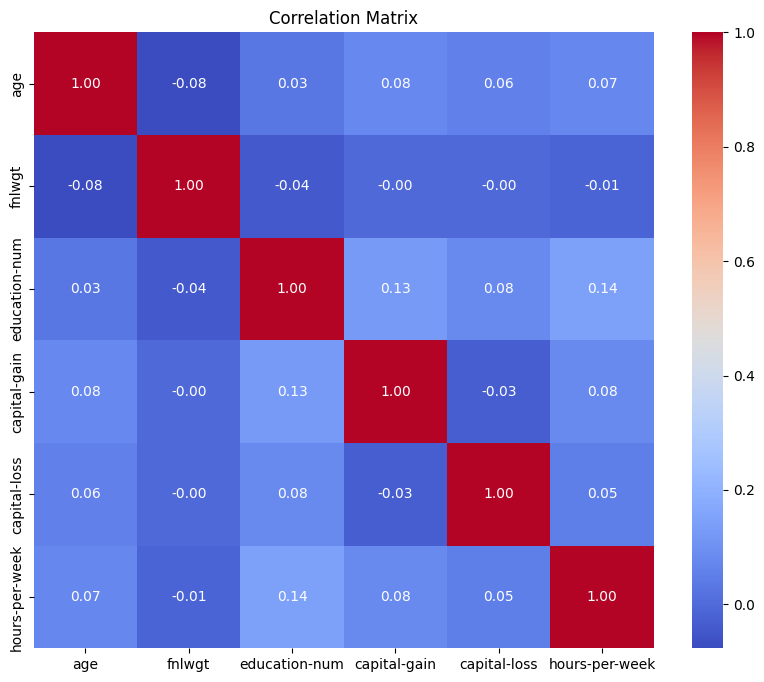

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

The correlation heatmap shows no particularly strong linear correlations among the numerical features. However, this analysis excludes categorical features and does not capture non-linear relationships. Decision-Tree can trace non-linear relationships better.

In [127]:
import pandas as pd
import scipy.stats as stats

categorical_cols = df_adult.select_dtypes(
    include=['object', 'category']
).columns

cramers_matrix = pd.DataFrame(
    index=categorical_cols,
    columns=categorical_cols,
    dtype=float
)

for col1 in categorical_cols:
    for col2 in categorical_cols:
        cross_tab = pd.crosstab(df_adult[col1], df_adult[col2])
        cramers_matrix.loc[col1, col2] = cramers_v(cross_tab)

In [122]:
cramers_matrix

,workclass,education,marital-status,occupation,relationship,race,sex,native-country,region
workclass,1.000000,0.106504,0.085351,0.428014,0.100336,0.058613,0.152587,0.045529,0.027500
education,0.106504,1.000000,0.090735,0.186952,0.122547,0.072844,0.092762,0.131296,0.088456
marital-status,0.085351,0.090735,1.000000,0.132560,0.488350,0.082274,0.461546,0.065603,0.047902
occupation,0.428014,0.186952,0.132560,1.000000,0.178855,0.079786,0.425338,0.068757,0.058221
relationship,0.100336,0.122547,0.488350,0.178855,1.000000,0.097208,0.647039,0.079264,0.047740
race,0.058613,0.072844,0.082274,0.079786,0.097208,1.000000,0.115984,0.414762,0.383484
sex,0.152587,0.092762,0.461546,0.425338,0.647039,0.115984,1.000000,0.060394,0.026703
native-country,0.045529,0.131296,0.065603,0.068757,0.079264,0.414762,0.060394,1.000000,1.000000
region,0.027500,0.088456,0.047902,0.058221,0.047740,0.383484,0.026703,1.000000,1.000000


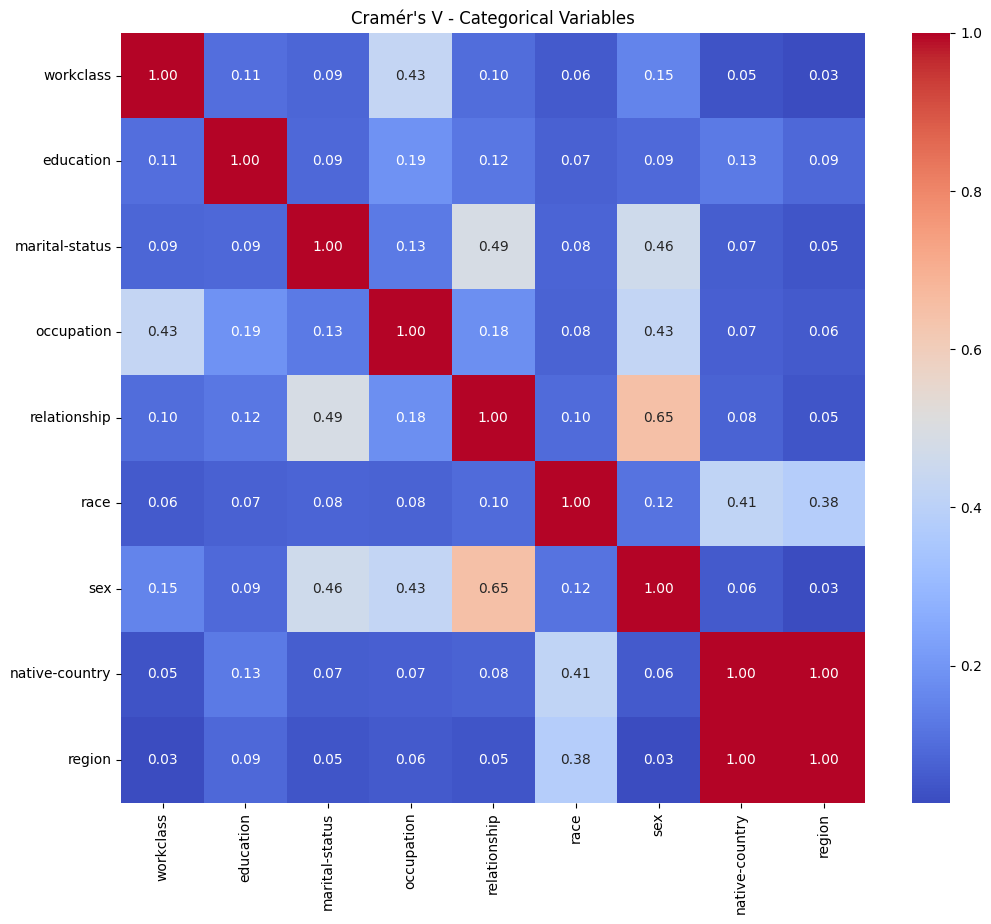

In [123]:
plt.figure(figsize=(12, 10))

sns.heatmap(cramers_matrix, annot=True, cmap='coolwarm', fmt='.2f')

plt.title("Cramér's V - Categorical Variables")
plt.show()

There's clearly a more varied heatmap for the catagorical data, notably .65 between sex and relationship... however I'm not sure how to interperet it.

In [124]:
pd.crosstab(df_adult['sex'], df_adult['relationship'])

relationship,Husband,Not-in-family,Other-relative,Own-child,Unmarried,Wife
sex,,,,,,
Female,1,5802,666,3330,3867,2275
Male,19370,6550,785,4154,1174,1


The strong association between sex and relationship indicates overlapping information between the Male/Female categories and the Husband/Wife household roles. This suggests redundancy between the two variables rather than revealing a particularly meaningful new relationship in the data.

In [125]:
 pd.crosstab(df_adult['sex'], df_adult['occupation'])

occupation,Adm-clerical,Armed-Forces,Craft-repair,Exec-managerial,Farming-fishing,Handlers-cleaners,Machine-op-inspct,Other-service,Priv-house-serv,Prof-specialty,Protective-serv,Sales,Tech-support,Transport-moving,Unknown
sex,,,,,,,,,,,,,,,
Female,3730,0,315,1724,95,253,793,2642,218,2203,122,1921,554,125,1246
Male,1810,14,5705,4260,1385,1793,2177,2166,14,3805,854,3487,866,2191,1507


Sex and occupation are associated (Cramér's V = 0.45), with substantial differences in occupational representation between males and females. Interperetation is another project however. The association between sex and occupation may warrant further investigation of factors such as individual preferences, opportunities and obstacles, social roles and expectations, and possible biological or psychological influences.

Q1.6 Run a statistical test of association between each feature and the target (e.g., point biserial correlation or ANOVA F-test for numeric features, chi-square test for categorical features). Rank the top 8 features by statistical significance and compare this ranking, qualitatively, to what you expect the feature importances in Exercise 2 to look like.

In [131]:
from scipy import stats
import pandas as pd

categorical_cols = df_adult.select_dtypes(
    include=['object', 'category']
).columns

for col in categorical_cols:
    cross_tab = pd.crosstab(df_adult[col], y)

    chi2, p, dof, expected = stats.chi2_contingency(
        cross_tab,
        correction=False
    )

    print(f"{col}: p-value = {p:.5f}")

workclass: p-value = 0.00000
education: p-value = 0.00000
marital-status: p-value = 0.00000
occupation: p-value = 0.00000
relationship: p-value = 0.00000
race: p-value = 0.00000
sex: p-value = 0.00000
native-country: p-value = 0.00000
region: p-value = 0.00000


The p-values are indeed not exactly zero, but extremely small, which means there's a very strong statistical association between these categorical features and the target variable.

The p-values are indeed not exactly zero, but extremely small, which means there's a very strong statistical association between these categorical features and the target variable. It suggests that the observed relationships are highly unlikely to have occurred by random chance.

In [132]:
from scipy.stats import pointbiserialr

feature_associations = {}

# Categorical features -> Cramer's V
categorical_cols = df_adult.select_dtypes(
    include=['object', 'category']
).columns

for col in categorical_cols:
    cross_tab = pd.crosstab(df_adult[col], y)
    feature_associations[col] = cramers_v(cross_tab)


# Numerical features -> Absolute Point-Biserial Correlation
y_numeric = y.astype('category').cat.codes

numerical_cols = df_adult.select_dtypes(include='number').columns

for col in numerical_cols:
    if col != 'fnlwgt':
        correlation, p_value = pointbiserialr(
            df_adult[col],
            y_numeric
        )
        feature_associations[col] = abs(correlation)


# Rank all features by association with income
ranked_features = pd.Series(feature_associations).sort_values(
    ascending=False
)

print(ranked_features.head(8))

relationship      0.454535
marital-status    0.448430
education         0.366521
occupation        0.350307
education-num     0.333156
age               0.229949
hours-per-week    0.228052
capital-gain      0.222448
dtype: float64


Here I use **Cramér's V** for categorical features and **absolute point-biserial correlation** for numerical features to measure their association with the target variable, income. It is worth noting that categorical features can be further decomposed to examine which individual categories contribute to the observed association. For example which specific ocupations contribute most.  **Cramér's V is derived from the Chi-square**. For numerical features, absolute point-biserial correlation provides a direct measure of association with the binary income target; ANOVA would be useful for comparing numerical variables across categorical groups, such as regions or deliberately created buckets, but not normally across cross-validation folds.

Nominal catagorical, binary catagorical (in the income target), ordinal catagorical, and numeric targets might best be suited to different methods.

Q1.7 Analyze the numerical features with and without standardization (zero mean, unit variance). Plot the feature distributions with and without standardization, and decide which version is more suitable for the models used in this assignment.

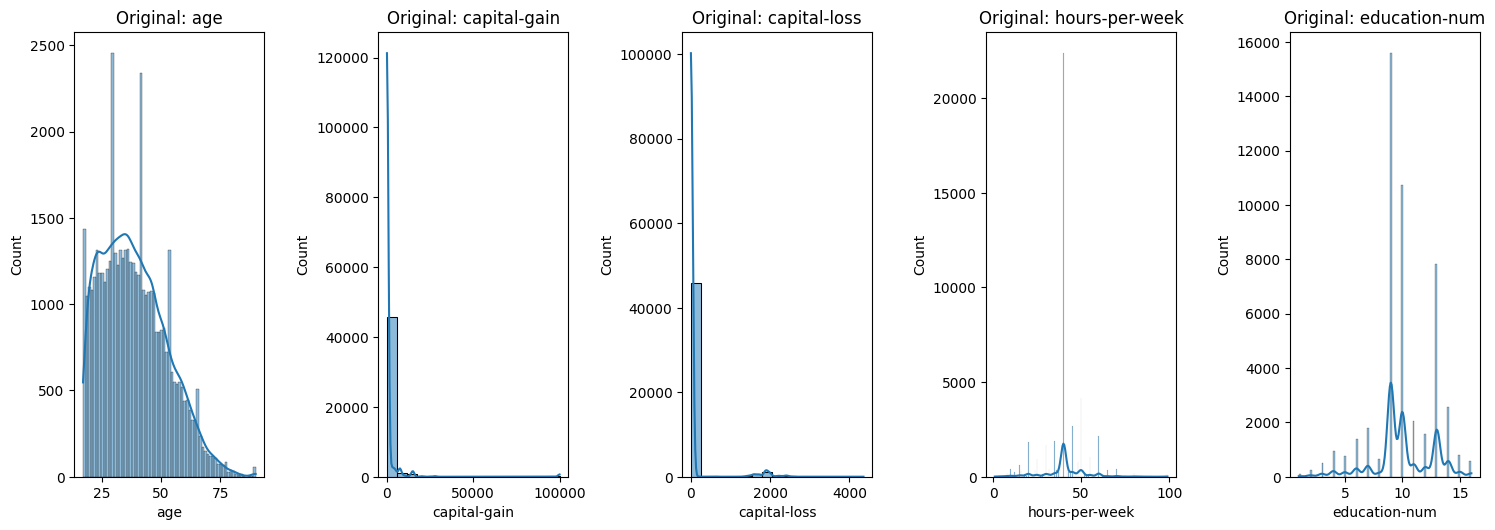

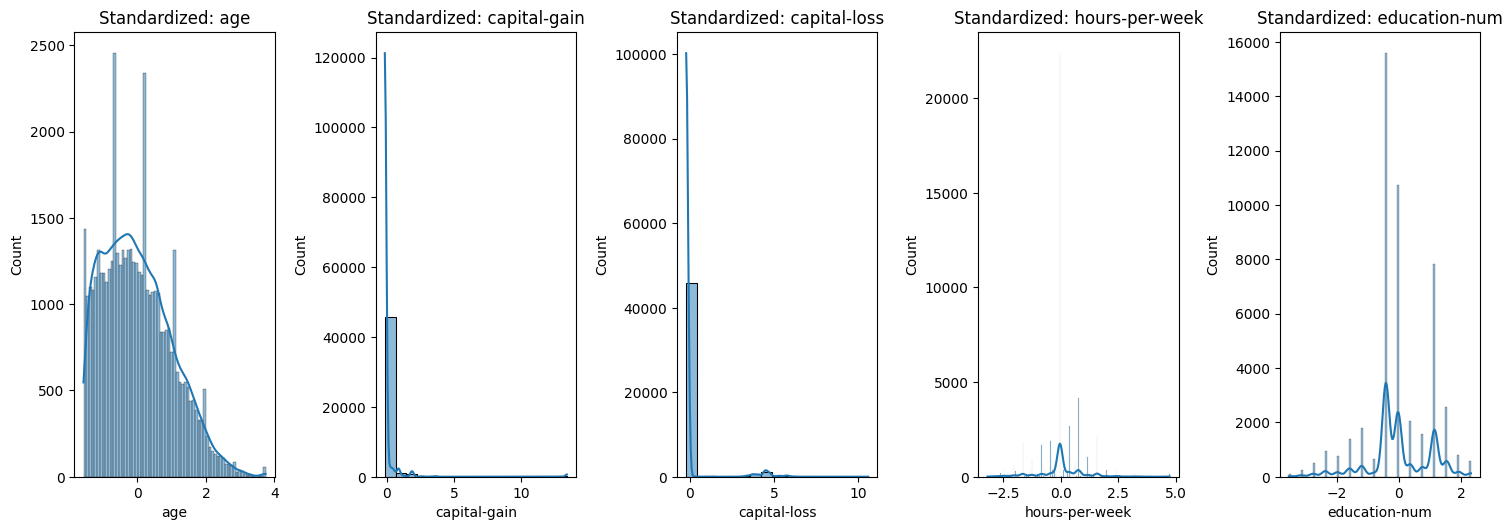

Descriptive statistics for original numerical features:
                age  capital-gain  capital-loss  hours-per-week  education-num
count  47975.000000  47975.000000  47975.000000    47975.000000   47975.000000
mean      38.645190   1067.254508     87.388765       40.413882      10.067764
std       13.728277   7374.008991    402.721453       12.389955       2.560392
min       17.000000      0.000000      0.000000        1.000000       1.000000
25%       28.000000      0.000000      0.000000       40.000000       9.000000
50%       37.000000      0.000000      0.000000       40.000000      10.000000
75%       48.000000      0.000000      0.000000       45.000000      12.000000
max       90.000000  99999.000000   4356.000000       99.000000      16.000000

Descriptive statistics for standardized numerical features:
                age  capital-gain  capital-loss  hours-per-week  education-num
count  4.797500e+04  4.797500e+04  4.797500e+04    4.797500e+04   4.797500e+04
mean   1.85133

In [134]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols_for_std = [
    'age', 'capital-gain', 'capital-loss', 'hours-per-week', 'education-num'
] # Exclude 'fnlwgt' as it's a sampling weight

# Create a copy for standardization to avoid modifying original df_adult directly for this analysis
df_numerical = df_adult[numerical_cols_for_std].copy()

# Plot original distributions
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols_for_std):
    plt.subplot(2, len(numerical_cols_for_std), i + 1)
    sns.histplot(df_numerical[col], kde=True)
    plt.title(f'Original: {col}')
plt.tight_layout()
plt.show()

# EDA demonstration of standardization on numerical features.
# This scaled dataframe is for visualization only and is not used for model training.
scaler = StandardScaler()
df_numerical_scaled = pd.DataFrame(
    scaler.fit_transform(df_numerical),
    columns=numerical_cols_for_std,
    index=df_numerical.index
)

# Plot standardized distributions
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols_for_std):
    plt.subplot(2, len(numerical_cols_for_std), i + 1)
    sns.histplot(df_numerical_scaled[col], kde=True)
    plt.title(f'Standardized: {col}')
plt.tight_layout()
plt.show()

print("Descriptive statistics for original numerical features:")
print(df_numerical.describe())
print("\nDescriptive statistics for standardized numerical features:")
print(df_numerical_scaled.describe())

Standardization transforms the data such that each feature now has a mean close to 0 and a standard deviation close to 1, while preserving the original shape of the distribution.

**Tree-based models such as Decision Trees and Random Forest models are generally not sensitive to the scale of features**. Their decision-making process involves splitting data based on feature thresholds (e.g., 'age > 30'). So we could use unstandardiszed numerical data with no downside.

**SVMs are sensitive to feature scaling.** Features with larger ranges will dominate distance calculations, giving improper priority to those features. Standardization prevents features with larger magnitudes from distorting the model and are needed for SVMs.

Data cleaning before the train/test split: The earlier cleaning steps do not introduce data leakage because they use fixed rules rather than information learned from the dataset or target variable. Missing workclass and occupation values were assigned the explicit category Unknown, selected incomplete rows were removed according to a predefined missing-value rule, and countries were mapped to predefined geographic regions. None of these operations estimate parameters from the data or use income to determine how observations are transformed.

Q1.8 Assemble your missing-value handling, outlier treatment, encoding, and standardization steps into a single leak-free preprocessing pipeline (e.g., using ColumnTransformer and Pipeline), fitted only on the training fold and applied unchanged to the validation and test data. Explain, with a concrete example from your own pipeline, how fitting any preprocessing step on the full dataset before splitting would cause data leakage.

Data cleaning before the train/test split: The earlier cleaning steps do not introduce data leakage because they use fixed rules rather than information learned from the dataset or target variable. Missing workclass and occupation values were assigned the explicit category Unknown, selected incomplete rows were removed according to a predefined missing-value rule, and countries were mapped to predefined geographic regions. None of these operations estimate parameters from the data or use income to determine how observations are transformed.

**Data-dependent transformations, such as standardization, are fitted only after the train/test split.**

In [111]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder


X = df_adult.drop(columns=['education', 'native-country'])
# (here using 'education-num' which is ordinal and 'region' for splits instead)
y = adult_data.target.loc[df_adult.index]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

categorical_cols = X_train.select_dtypes(
    include=['object', 'category', 'string']
).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

In [135]:
print("Missing both workclass + occupation:", len(missing_both))
print("Other missing:", len(other_missing))

Missing both workclass + occupation: 2799
Other missing: 867
